# Model Analysis Notebook

In [ ]:
import pickle
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ATLAS)

import os
import sys
sys.path.append(str(Path(os.getcwd()).parent.absolute()))
import colorlog
logger = colorlog.getLogger()

In [ ]:
def get_results_dataframes(results_dir: Path):
    res = {}
    summary_df = []
    log_df = []
    pd_fa_keys = ['max_sp_pd', 'max_sp_fa', 'max_sp_pd_val', 'max_sp_fa_val', 'max_sp_pd_op', 'max_sp_fa_op']
    history_items = []
    for item in results_dir.iterdir():
        if not item.is_dir():
            logger.info(f'Skipping {item.name} since it is not a directory.')
            continue
        logger.info(f'Processing {item.name}...')
        fold_match = re.search(r"sort_(\d+)", item.name)
        init_match = re.search(r"init_(\d+)", item.name)
        with open(item / 'results.pic', 'rb') as f:
            d = pickle.load(f)
        history_items += list(d['history'].keys())
        summary_dict = d['history'].pop('summary')
        d['history'].pop('reference')
        for key in pd_fa_keys:
            metric, approved, total = summary_dict.pop(key)
            summary_dict[key] = metric
            summary_dict[f'{key}_approved'] = approved
            summary_dict[f'{key}_total'] = total

        summary_dict['fold'] = int(fold_match.group(1)) if fold_match else None
        summary_dict['init'] = int(init_match.group(1)) if init_match else None
        d['history']['fold'] = summary_dict['fold']
        d['history']['init'] = summary_dict['init']

        summary_df.append(summary_dict)
        log_df.append(d['history'])
    history_items = set(history_items)
    history_items.discard('patience')
    history_items.discard('summary')
    history_items.discard('reference')
    history_items.discard('fold')
    history_items.discard('init')
    history_items = sorted(history_items)

    summary_df = pd.DataFrame.from_records(summary_df)
    max_sp_idx = summary_df['max_sp_pd_val'].idxmax()
    logger.info(f"Best model: {max_sp_idx} with max_sp_pd_val: {summary_df.loc[max_sp_idx, 'max_sp_pd_val']}")
    res['summary_df'] = summary_df
    res['max_sp_idx'] = max_sp_idx

    log_df = pd.DataFrame.from_records(log_df)
    res['log_df'] = log_df
    res['history_items'] = history_items

    max_epochs = log_df['accuracy'].apply(len).max()
    folds = log_df['fold'].unique()
    inits = log_df['init'].unique()
    cols = pd.MultiIndex.from_product(
        [history_items, folds, inits], names=['metric', 'fold', 'init']
    )
    history_df = pd.DataFrame(np.nan, index=range(max_epochs), columns=cols)
    for _, row in log_df.iterrows():
        for metric_name in history_items:
            col_name = (metric_name, row['fold'], row['init'])
            for i, value in enumerate(row[metric_name]):
                history_df.loc[i, col_name] = value
    logger.info(f'History DataFrame shape: {history_df.shape}')
    res['history_df'] = history_df
    return res

In [ ]:
model_results = {
    'vqat0': get_results_dataframes(
        Path('/media/lucasbanunes/KINGSTON/data/cern/quantization/vqat0')
    ),
    'vnoq0': get_results_dataframes(
        Path('/media/lucasbanunes/KINGSTON/data/cern/quantization/vnoq0')
    )
}
model_results['vqat0']['label'] = 'QAT'
model_results['vnoq0']['label'] = 'NoQ'

FileNotFoundError: [Errno 2] No such file or directory: '/media/lucasbanunes/KINGSTON/data/cern_data/quantization/vqat0'

# Best Model Training curves

In [14]:
def plot_training_curves(model_results, metric_name: str, metric_label: str, colors, ax=None):
    log_df = model_results['log_df']
    summary_df = model_results['summary_df']
    max_sp_idx = model_results['max_sp_idx']
    if ax is None:
        ax = plt.gca()
    ax.grid(linestyle='--', alpha=0.1, color='k')
    model_label = model_results['label']
    # if model_label := model_results.get('label'):
    #     ax.plot([], [], ' ', label=model_label)
    # ax.plot([], [], ' ', label=f"{model_label} Fold {summary_df.loc[max_sp_idx, 'fold']}")
    # ax.plot([], [], ' ', label=f"{model_label} Init {summary_df.loc[max_sp_idx, 'init']}")
    ax.plot([], [], ' ', label=f"{model_label} Epochs {len(log_df.loc[max_sp_idx, 'loss'])}")
    ax.plot(log_df.loc[max_sp_idx, metric_name], label=f'{metric_label}', color=colors[0])
    val_name = f'val_{metric_name}'
    if val_name in log_df.columns:
        ax.plot(log_df.loc[max_sp_idx, val_name], label=f'Val {metric_label}', color=colors[1])
    ax.set(
        title=f'{metric_label} Training Curve',
        xlabel='Epochs',
        ylabel=metric_label
    )
    return ax

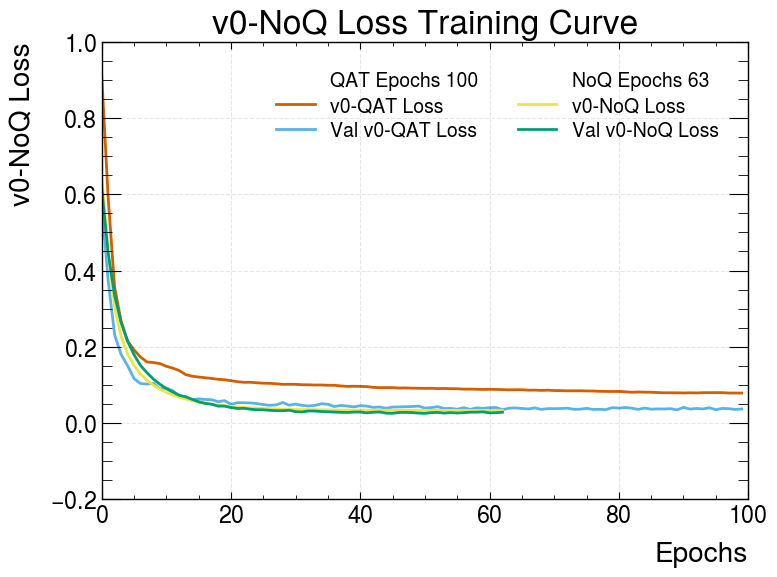

In [15]:
fig, ax = plt.subplots()
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax = plot_training_curves(
    model_results=model_results['vqat0'],
    metric_name='loss',
    metric_label='v0-QAT Loss',
    ax=ax,
    colors=color_cycle[:2]
)
ax = plot_training_curves(
    model_results=model_results['vnoq0'],
    metric_name='loss',
    metric_label='v0-NoQ Loss',
    ax=ax,
    colors=color_cycle[3:5]
)
ax.legend(ncols=2)
fig.tight_layout()

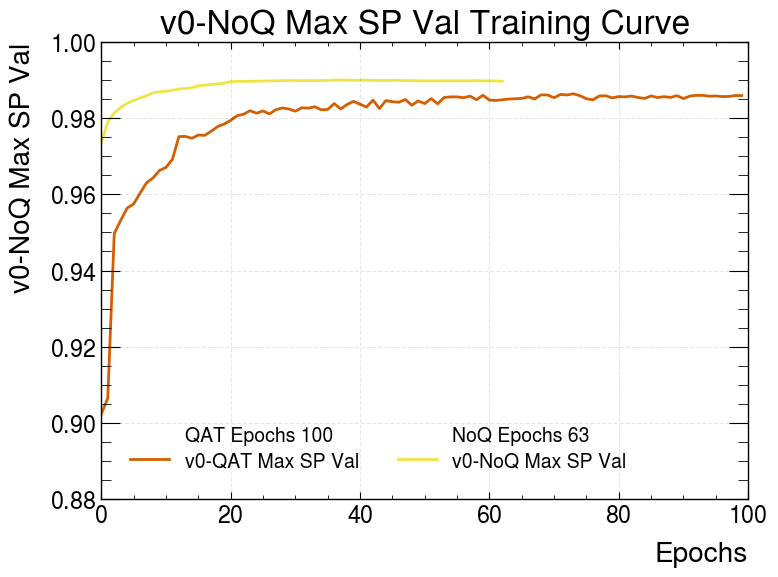

In [16]:
fig, ax = plt.subplots()
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax = plot_training_curves(
    model_results=model_results['vqat0'],
    metric_name='max_sp_val',
    metric_label='v0-QAT Max SP Val',
    ax=ax,
    colors=color_cycle[:2]
)
ax = plot_training_curves(
    model_results=model_results['vnoq0'],
    metric_name='max_sp_val',
    metric_label='v0-NoQ Max SP Val',
    ax=ax,
    colors=color_cycle[3:5]
)
ax.legend(ncols=2)
fig.tight_layout()

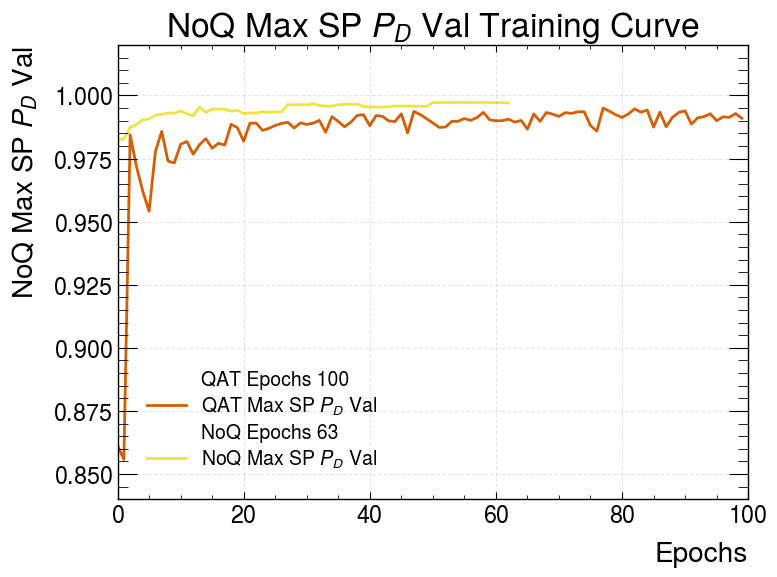

In [20]:
fig, ax = plt.subplots()
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax = plot_training_curves(
    model_results=model_results['vqat0'],
    metric_name='max_sp_pd_val',
    metric_label=r'QAT Max SP $P_D$ Val',
    ax=ax,
    colors=color_cycle[:2]
)
ax = plot_training_curves(
    model_results=model_results['vnoq0'],
    metric_name='max_sp_pd_val',
    metric_label=r'NoQ Max SP $P_D$ Val',
    ax=ax,
    colors=color_cycle[3:5]
)
ax.legend(ncols=1)
fig.tight_layout()

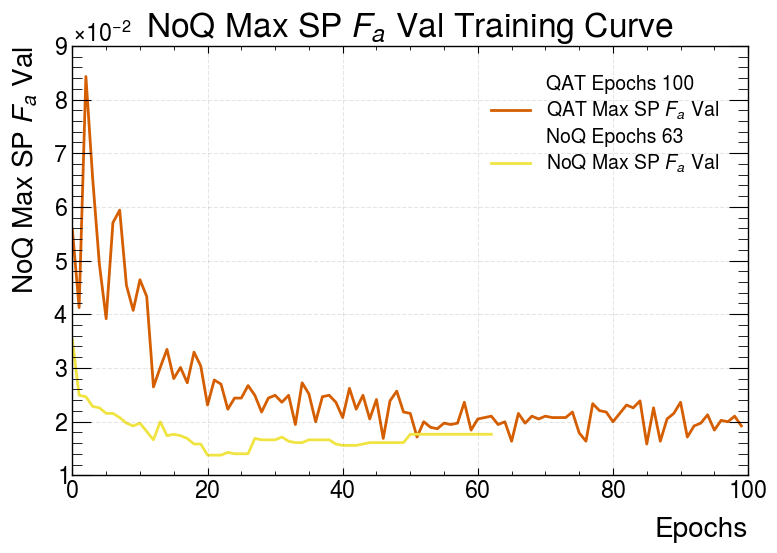

In [19]:
fig, ax = plt.subplots()
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax = plot_training_curves(
    model_results=model_results['vqat0'],
    metric_name='max_sp_fa_val',
    metric_label=r'QAT Max SP $F_a$ Val',
    ax=ax,
    colors=color_cycle[:2]
)
ax = plot_training_curves(
    model_results=model_results['vnoq0'],
    metric_name='max_sp_fa_val',
    metric_label=r'NoQ Max SP $F_a$ Val',
    ax=ax,
    colors=color_cycle[3:5]
)
ax.legend(ncols=1)
fig.tight_layout()

In [9]:
def plot_init_mean_curve(model_results, metric_name, fold: int | None = None, metric_label=None, hline: float | None = None):
    history_df = model_results['history_df']
    folds = model_results['log_df']['fold'].unique()
    model_label = model_results['label']
    fig, ax = plt.subplots()
    ax.grid(linestyle='--', alpha=0.1, color='k')
    ax.plot([], [], ' ', label=model_label)
    if hline is not None:
        ax.axhline(hline, color='k', linestyle='--', alpha=0.3)
    for fold in folds:
        metric_df = history_df.loc[:, (metric_name, fold)]
        metric_mean = metric_df.mean(axis=1).values
        lines = ax.plot(metric_mean, label=f'Fold {fold}')
        metric_std = metric_df.std(axis=1).values
        upper_bound = metric_mean + 3*metric_std
        upper_bound[upper_bound > 1.0] = 1.0
        lower_bound = metric_mean - 3*metric_std
        lower_bound[lower_bound < 0.0] = 0.0
        ax.fill_between(range(len(metric_mean)), lower_bound, upper_bound, alpha=0.2, color=lines[0].get_color())
    ax.legend()
    ax.set(
        title=rf'{model_label} {metric_label} $\mu \pm 3\sigma$',
        xlabel='Epochs',
        ylabel=metric_label
    )
    return fig, ax

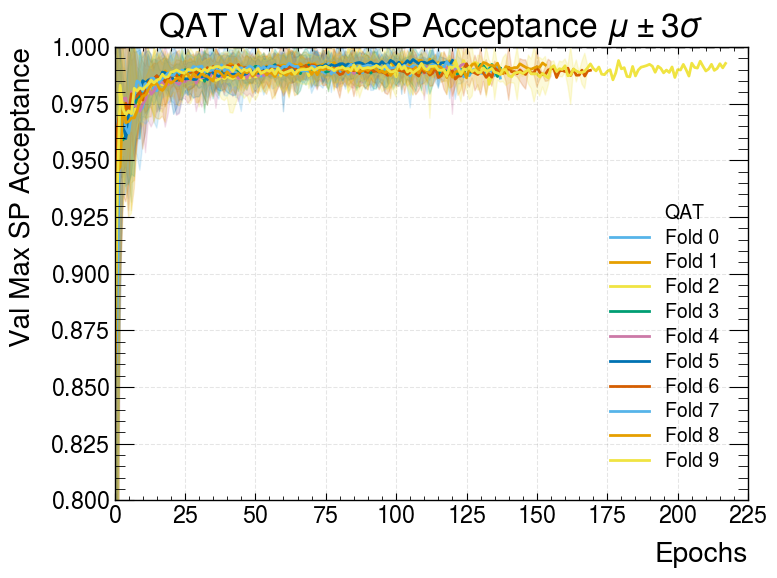

In [10]:
fig, ax = plot_init_mean_curve(model_results['vqat0'], 'max_sp_pd_val', metric_label='Val Max SP Acceptance', hline=1.0)
ax.set(ylim=(0.8, 1.0))
fig.tight_layout()

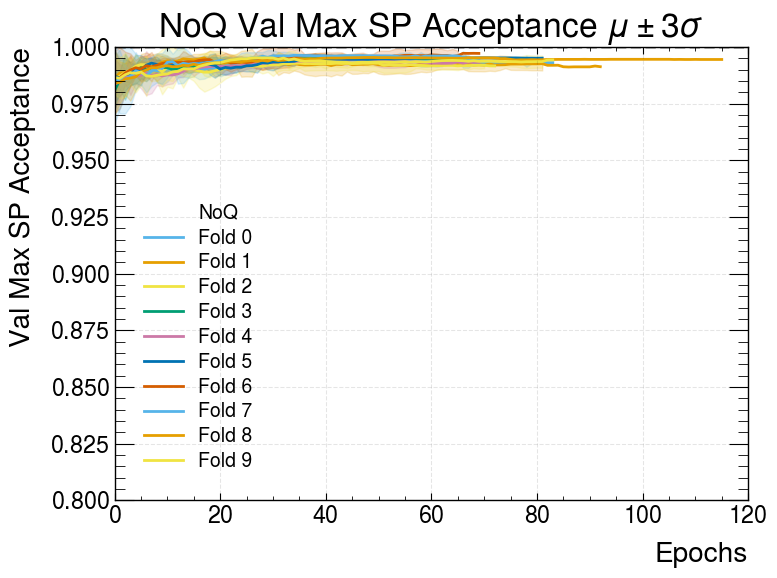

In [11]:
fig, ax = plot_init_mean_curve(model_results['vnoq0'], 'max_sp_pd_val', metric_label='Val Max SP Acceptance', hline=1.0)
ax.set(ylim=(0.8, 1.0))
fig.tight_layout()

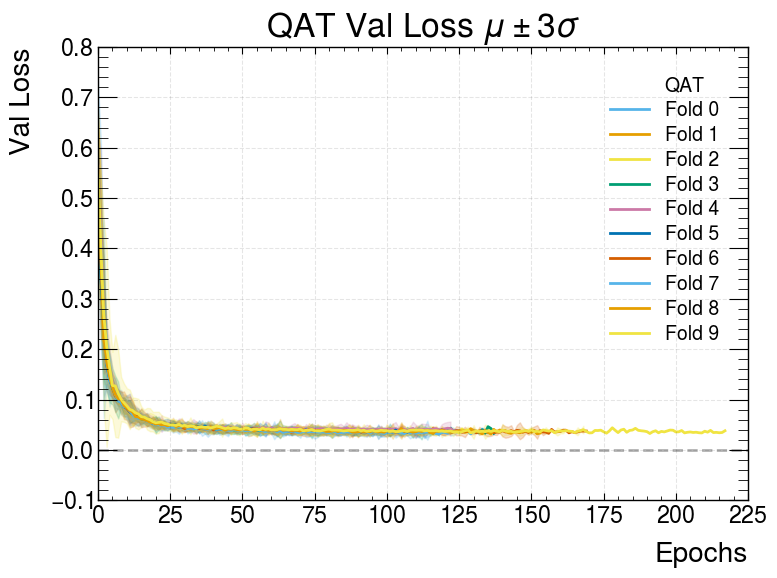

In [12]:
fig, ax = plot_init_mean_curve(model_results['vqat0'], 'val_loss', metric_label='Val Loss', hline=0)
fig.tight_layout()

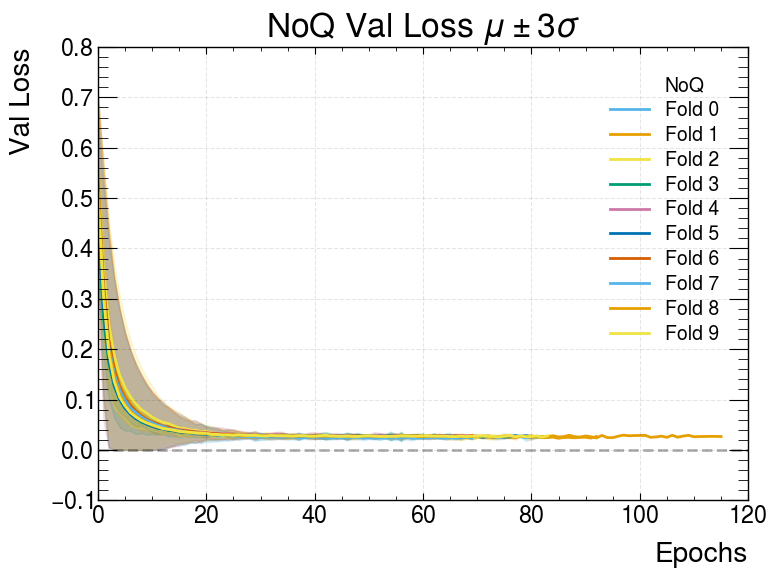

In [13]:
fig, ax = plot_init_mean_curve(model_results['vnoq0'], 'val_loss', metric_label='Val Loss', hline=0)
fig.tight_layout()